# 01 – EDA: Undirected Unweighted Graph Analysis

**Global Cargo Shipping Network (GCSN) — 2015 vs 2025**

Methodology follows **Kaluza et al. (2010)**, *J. R. Soc. Interface*, who analysed the 2007 GCSN.

### Analyses performed
1. Graph construction (directed + undirected, unweighted)
2. Basic statistics — N, E, density, component structure
3. Degree distribution P(k) with power-law fit (MLE exponent µ)
4. Clustering coefficient C and C(k) vs k
5. Characteristic path length L (sampled on GCC)
6. Small-world properties (σ coefficient)
7. Degree-degree correlation: assortativity r and KNN k_nn(k)
8. Rich-club coefficient
9. Summary table — 2015 vs 2025 vs Paper 2007 baseline


In [1]:
import os
import warnings
warnings.filterwarnings('ignore')

import pandas as pd
import numpy as np
import networkx as nx
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
from collections import defaultdict
from scipy import stats

try:
    plt.style.use('seaborn-v0_8-whitegrid')
except Exception:
    plt.style.use('ggplot')

plt.rcParams.update({
    'figure.figsize': (8, 5),
    'figure.dpi': 100,
    'font.size': 12,
    'axes.labelsize': 13,
    'axes.titlesize': 14,
    'legend.fontsize': 10,
})

FIG_DIR = '../Figures/'
os.makedirs(FIG_DIR, exist_ok=True)

# Paper (Kaluza et al. 2010) baseline metrics — full GCSN, year 2007
PAPER_2007 = {
    'nodes': 951,
    'mean_degree': 44.61,
    'clustering': 0.49,
    'path_length': 2.50,
    'mu': 1.71,
    'journeys_per_link': 10.4,
    'strength_exponent_eta': 1.02,
    'superlinear_alpha': 1.36,
}

print('All imports OK')
print(f'NetworkX version: {nx.__version__}')
print(f'Figures will be saved to: {os.path.abspath(FIG_DIR)}')


All imports OK
NetworkX version: 3.4.2
Figures will be saved to: c:\Git\NS_Project\GCSN-Analysis\Figures


## 1. Load Edge Lists


In [2]:
DATA_2015 = '../EdgeList/shipping_network_2015.csv'
DATA_2025 = '../EdgeList/shipping_network_2025.csv'

df_2015 = pd.read_csv(DATA_2015)
df_2025 = pd.read_csv(DATA_2025)

for year, df in [('2015', df_2015), ('2025', df_2025)]:
    all_nodes = set(df['source']) | set(df['target'])
    print(f'\n{"="*50}')
    print(f'  {year} Edge List')
    print(f'{"="*50}')
    print(f'  Directed edges : {len(df):>9,}')
    print(f'  Unique ports   : {len(all_nodes):>9,}')
    print(f'  Weight min     : {df["weight"].min():>9,}')
    print(f'  Weight max     : {df["weight"].max():>9,}')
    print(f'  Weight mean    : {df["weight"].mean():>9.2f}')
    print(f'  Total voyages  : {df["weight"].sum():>9,}')
    print(f'\n  Sample rows:')
    print(df.head(4).to_string(index=False))



  2015 Edge List
  Directed edges :   188,545
  Unique ports   :     7,097
  Weight min     :         1
  Weight max     :    10,269
  Weight mean    :      9.50
  Total voyages  : 1,791,795

  Sample rows:
      source       target  weight
chn-shanghai   chn-dalian    1672
chn-shanghai chn-chn-1154       1
chn-shanghai  chn-wenzhou     688
chn-shanghai chn-zhoushan    1264

  2025 Edge List
  Directed edges :   182,300
  Unique ports   :     7,717
  Weight min     :         1
  Weight max     :    12,779
  Weight mean    :     10.78
  Total voyages  : 1,965,325

  Sample rows:
     source           target  weight
tur-trabzon     tur-istanbul      28
tur-trabzon tur-rumelifeneri      20
tur-trabzon       tur-tur-25       1
tur-trabzon       rou-sulina       2


## 2. Build Unweighted Graphs

Following Kaluza et al., we construct:
- **Directed** unweighted graph (Gd): edge u→v if any ship travelled that route
- **Undirected** unweighted graph (Gu): edge {u,v} if either u→v or v→u exists


In [3]:
def build_unweighted_graphs(df):
    """Build directed + undirected unweighted graphs from an edge-list DataFrame."""
    Gd = nx.DiGraph()
    Gd.add_edges_from(zip(df['source'], df['target']))

    Gu = nx.Graph()
    Gu.add_edges_from(zip(df['source'], df['target']))

    return Gd, Gu


def graph_summary(Gd, Gu, year):
    """Print directed + undirected basic stats."""
    gcc = Gu.subgraph(max(nx.connected_components(Gu), key=len))
    gcc_frac = gcc.number_of_nodes() / Gu.number_of_nodes() * 100

    print(f'\n{"="*52}')
    print(f'  {year} Network Summary')
    print(f'{"="*52}')
    print(f'  DIRECTED GRAPH')
    print(f'    Nodes                     : {Gd.number_of_nodes():>8,}')
    print(f'    Edges                     : {Gd.number_of_edges():>8,}')
    print(f'    Density                   : {nx.density(Gd):>8.6f}')
    print(f'    Strongly Connected Comps  : {nx.number_strongly_connected_components(Gd):>8,}')
    print(f'    Weakly Connected Comps    : {nx.number_weakly_connected_components(Gd):>8,}')
    print(f'  UNDIRECTED GRAPH')
    print(f'    Nodes                     : {Gu.number_of_nodes():>8,}')
    print(f'    Edges                     : {Gu.number_of_edges():>8,}')
    print(f'    Density                   : {nx.density(Gu):>8.6f}')
    print(f'    Connected Components      : {nx.number_connected_components(Gu):>8,}')
    print(f'    GCC size (nodes)          : {gcc.number_of_nodes():>8,}  ({gcc_frac:.1f}%)')
    print(f'    GCC size (edges)          : {gcc.number_of_edges():>8,}')
    mean_k = np.mean([d for _, d in Gu.degree()])
    max_k  = max(d for _, d in Gu.degree())
    print(f'    Mean degree <k>           : {mean_k:>8.2f}')
    print(f'    Max degree                : {max_k:>8,}')


Gd_2015, Gu_2015 = build_unweighted_graphs(df_2015)
Gd_2025, Gu_2025 = build_unweighted_graphs(df_2025)

graph_summary(Gd_2015, Gu_2015, '2015')
graph_summary(Gd_2025, Gu_2025, '2025')



  2015 Network Summary
  DIRECTED GRAPH
    Nodes                     :    7,097
    Edges                     :  188,545
    Density                   : 0.003744
    Strongly Connected Comps  :      219
    Weakly Connected Comps    :        8
  UNDIRECTED GRAPH
    Nodes                     :    7,097
    Edges                     :  145,745
    Density                   : 0.005788
    Connected Components      :        8
    GCC size (nodes)          :    7,081  (99.8%)
    GCC size (edges)          :  145,736
    Mean degree <k>           :    41.07
    Max degree                :    1,233

  2025 Network Summary
  DIRECTED GRAPH
    Nodes                     :    7,717
    Edges                     :  182,300
    Density                   : 0.003062
    Strongly Connected Comps  :      203
    Weakly Connected Comps    :        5
  UNDIRECTED GRAPH
    Nodes                     :    7,717
    Edges                     :  139,499
    Density                   : 0.004686
    Connec

## 3. Degree Distribution P(k)

Kaluza et al. Fig. 2a: right-skewed P(k); fitted with power law P(k) ~ k^{-µ}.

We use **log-binning** (geometric-mean bin centres) and the **MLE estimator** for the power-law exponent µ (Clauset, Shalizi & Newman 2009).


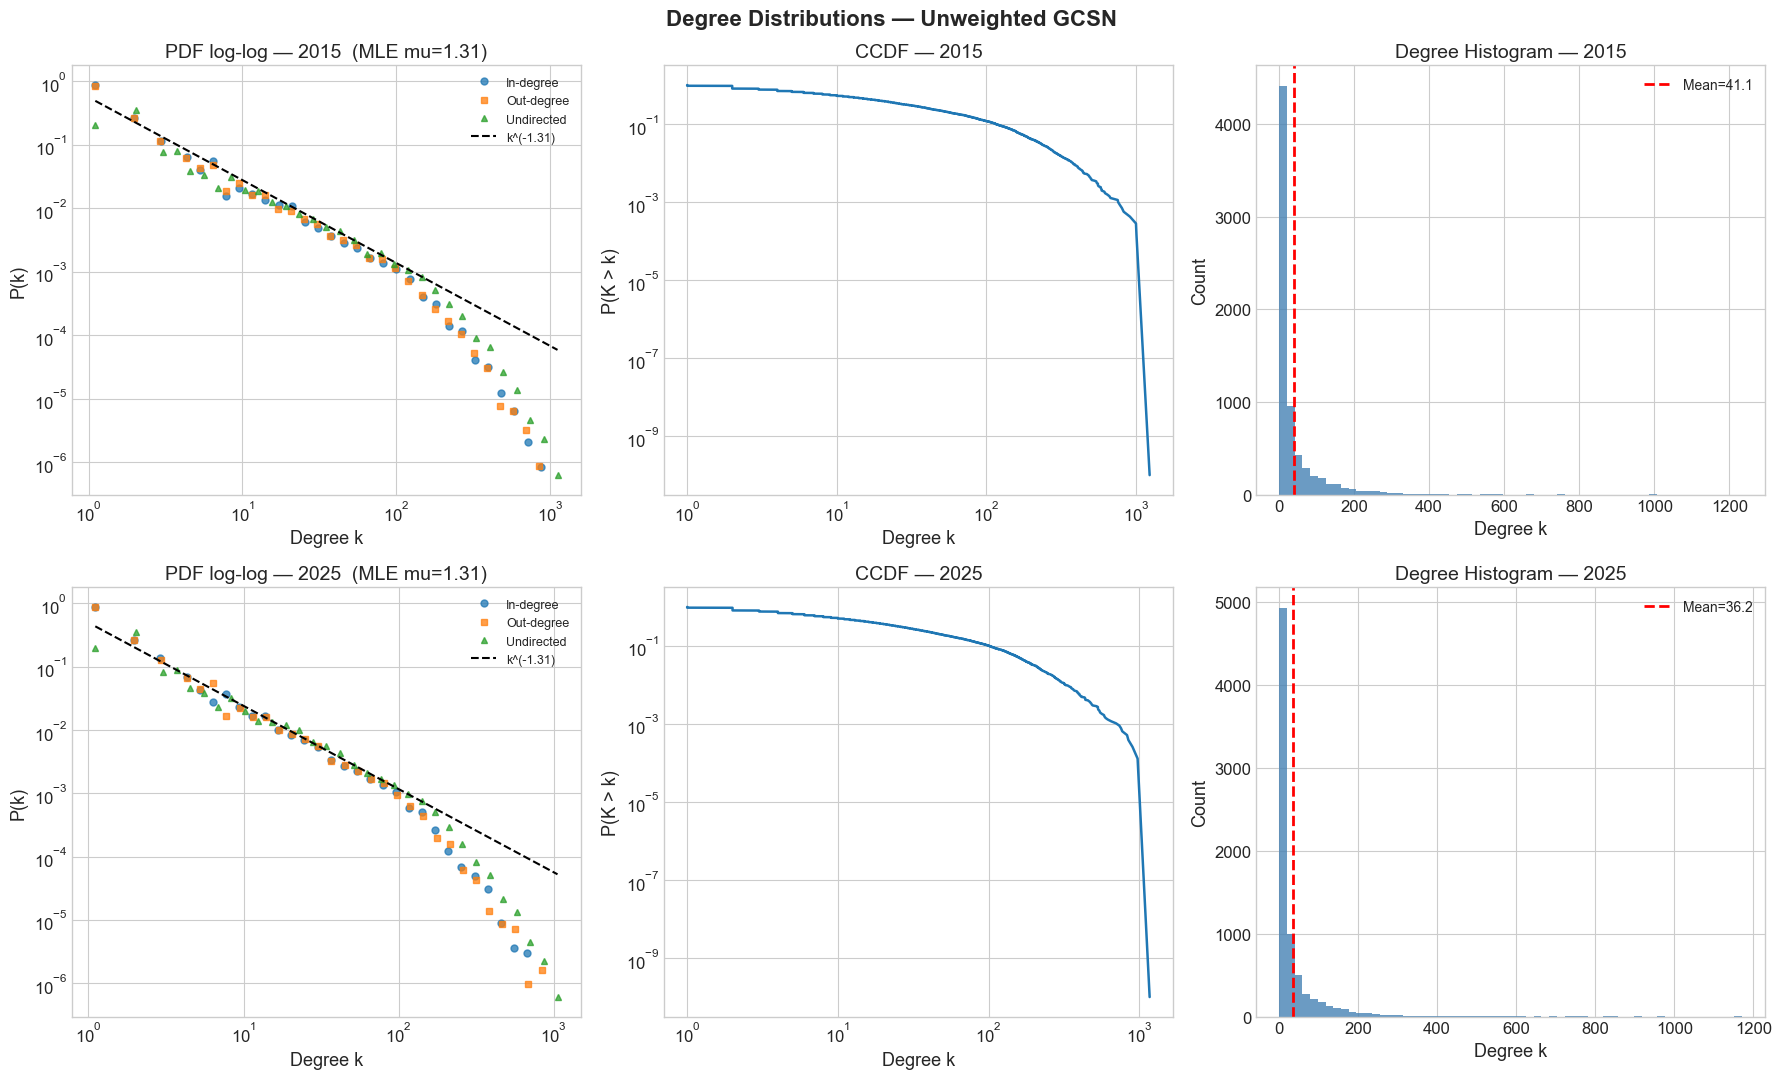


Metric                                     2015     2025  Paper07
Mean in-degree                            26.57    23.62        —
Mean out-degree                           26.57    23.62        —
Mean undirected degree <k>                41.07    36.15    44.61
Max degree                                1,233    1,171        —
Power-law exponent mu (MLE)               1.306    1.314     1.71


In [4]:
def log_binning(data, n_bins=35):
    """Log-spaced histogram with geometric-mean bin centres (density=True)."""
    data = np.asarray(data, dtype=float)
    data = data[data > 0]
    if len(data) == 0:
        return np.array([]), np.array([])
    bins = np.logspace(np.log10(data.min()), np.log10(data.max()), n_bins + 1)
    hist, edges = np.histogram(data, bins=bins, density=True)
    centres = np.sqrt(edges[:-1] * edges[1:])  # geometric mean
    mask = hist > 0
    return centres[mask], hist[mask]


def mle_powerlaw_exponent(data, x_min=1):
    """
    MLE estimator for continuous power-law exponent alpha.
    P(k) ~ k^{-alpha} for k >= x_min.
    Formula: alpha = 1 + n * [sum_i ln(k_i / (x_min - 0.5))]^{-1}
    (Clauset, Shalizi & Newman 2009, Eq. 3.1 adapted for discrete).
    """
    data = np.asarray(data, dtype=float)
    data = data[data >= x_min]
    n = len(data)
    if n == 0:
        return np.nan
    alpha = 1.0 + n / np.sum(np.log(data / (x_min - 0.5)))
    return alpha


def compute_ccdf(data):
    """Complementary CDF: P(K > k)."""
    x = np.sort(data)
    n = len(x)
    y = 1.0 - np.arange(1, n + 1) / n
    return x, y


fig, axes = plt.subplots(2, 3, figsize=(18, 11))
fig.suptitle('Degree Distributions — Unweighted GCSN', fontsize=16, fontweight='bold')

deg_stats = {}

for row, (year, Gd, Gu) in enumerate([
    ('2015', Gd_2015, Gu_2015),
    ('2025', Gd_2025, Gu_2025)
]):
    in_deg  = np.array([d for _, d in Gd.in_degree()])
    out_deg = np.array([d for _, d in Gd.out_degree()])
    deg     = np.array([d for _, d in Gu.degree()])

    mu = mle_powerlaw_exponent(deg, x_min=1)

    # ---- Log-binned PDF ----
    k_in,  pk_in  = log_binning(in_deg)
    k_out, pk_out = log_binning(out_deg)
    k_u,   pk_u   = log_binning(deg)

    ax = axes[row, 0]
    ax.loglog(k_in,  pk_in,  'o', ms=5, alpha=0.75, label='In-degree')
    ax.loglog(k_out, pk_out, 's', ms=5, alpha=0.75, label='Out-degree')
    ax.loglog(k_u,   pk_u,   '^', ms=5, alpha=0.75, label='Undirected')
    # Power-law reference line anchored at median k
    k_fit = np.logspace(np.log10(max(k_u.min(), 1)), np.log10(k_u.max()), 200)
    anchor_idx = len(k_u) // 2
    if anchor_idx < len(k_u):
        scale = pk_u[anchor_idx] * k_u[anchor_idx] ** mu
        ax.loglog(k_fit, scale * k_fit**(-mu), 'k--', lw=1.5,
                  label=f'k^(-{mu:.2f})')
    ax.set_xlabel('Degree k')
    ax.set_ylabel('P(k)')
    ax.set_title(f'PDF log-log — {year}  (MLE mu={mu:.2f})')
    ax.legend(fontsize=9)

    # ---- CCDF ----
    x_ccdf, y_ccdf = compute_ccdf(deg)
    ax2 = axes[row, 1]
    ax2.loglog(x_ccdf, y_ccdf + 1e-10, '-', lw=1.8)
    ax2.set_xlabel('Degree k')
    ax2.set_ylabel('P(K > k)')
    ax2.set_title(f'CCDF — {year}')

    # ---- Linear histogram ----
    ax3 = axes[row, 2]
    ax3.hist(deg, bins=60, edgecolor='none', color='steelblue', alpha=0.8)
    ax3.axvline(deg.mean(), color='red', lw=2, linestyle='--',
                label=f'Mean={deg.mean():.1f}')
    ax3.set_xlabel('Degree k')
    ax3.set_ylabel('Count')
    ax3.set_title(f'Degree Histogram — {year}')
    ax3.legend()

    deg_stats[year] = {
        'mean_in': float(in_deg.mean()),
        'mean_out': float(out_deg.mean()),
        'mean_undirected': float(deg.mean()),
        'max_degree': int(deg.max()),
        'mu': float(mu),
        'in_deg': in_deg, 'out_deg': out_deg, 'deg': deg
    }

plt.tight_layout()
plt.savefig(FIG_DIR + '01_degree_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

print(f'\n{"="*62}')
print(f'{"Metric":<38} {"2015":>8} {"2025":>8} {"Paper07":>8}')
print(f'{"="*62}')
print(f'{"Mean in-degree":<38} {deg_stats["2015"]["mean_in"]:>8.2f} {deg_stats["2025"]["mean_in"]:>8.2f} {"—":>8}')
print(f'{"Mean out-degree":<38} {deg_stats["2015"]["mean_out"]:>8.2f} {deg_stats["2025"]["mean_out"]:>8.2f} {"—":>8}')
print(f'{"Mean undirected degree <k>":<38} {deg_stats["2015"]["mean_undirected"]:>8.2f} {deg_stats["2025"]["mean_undirected"]:>8.2f} {PAPER_2007["mean_degree"]:>8.2f}')
print(f'{"Max degree":<38} {deg_stats["2015"]["max_degree"]:>8,} {deg_stats["2025"]["max_degree"]:>8,} {"—":>8}')
print(f'{"Power-law exponent mu (MLE)":<38} {deg_stats["2015"]["mu"]:>8.3f} {deg_stats["2025"]["mu"]:>8.3f} {PAPER_2007["mu"]:>8.2f}')


## 4. Clustering Coefficient

Kaluza et al. report C = 0.49 for the full 2007 GCSN.  
We also plot C(k) vs k to check whether well-connected ports have lower clustering (hierarchical structure).


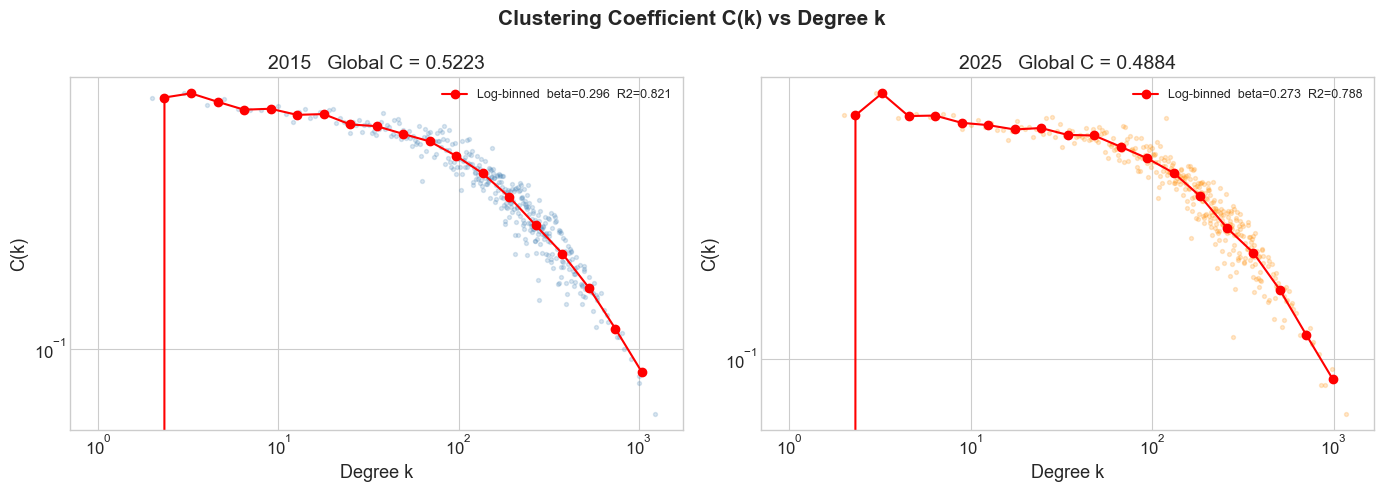


Metric                                     2015     2025  Paper07
Clustering coefficient C                 0.5223   0.4884     0.49
C(k) decay exponent beta                  0.296    0.273        —
C(k) fit R^2                              0.821    0.788        —


In [5]:
def clustering_analysis(Gu, year):
    """Global clustering coefficient and C(k) profile."""
    C_global = nx.average_clustering(Gu)

    clust = nx.clustering(Gu)
    deg   = dict(Gu.degree())

    ck_map = defaultdict(list)
    for node in Gu.nodes():
        k = deg[node]
        if k > 0:
            ck_map[k].append(clust[node])

    k_all = np.array(sorted(ck_map.keys()))
    c_all = np.array([np.mean(ck_map[k]) for k in k_all])

    # Log-bin C(k)
    if len(k_all) > 2:
        bins = np.logspace(np.log10(max(k_all.min(), 1)),
                           np.log10(k_all.max()), 22)
        k_bin, c_bin = [], []
        for i in range(len(bins) - 1):
            mask = (k_all >= bins[i]) & (k_all < bins[i + 1])
            if mask.sum() > 0:
                k_bin.append(np.sqrt(bins[i] * bins[i + 1]))
                c_bin.append(np.mean(c_all[mask]))
        k_bin = np.array(k_bin)
        c_bin = np.array(c_bin)
    else:
        k_bin, c_bin = k_all, c_all

    # Fit C(k) ~ k^{-beta}
    valid = (k_bin > 0) & (c_bin > 0)
    if valid.sum() >= 3:
        slope, intercept, r, p, _ = stats.linregress(
            np.log10(k_bin[valid]), np.log10(c_bin[valid]))
        beta = -slope
        r2   = r ** 2
    else:
        beta, r2 = np.nan, np.nan

    return {
        'C': C_global,
        'beta': beta,
        'r2': r2,
        'k_all': k_all, 'c_all': c_all,
        'k_bin': k_bin, 'c_bin': c_bin,
    }


res_c_2015 = clustering_analysis(Gu_2015, '2015')
res_c_2025 = clustering_analysis(Gu_2025, '2025')

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Clustering Coefficient C(k) vs Degree k', fontsize=15, fontweight='bold')

for ax, res, year, color in [
    (axes[0], res_c_2015, '2015', 'steelblue'),
    (axes[1], res_c_2025, '2025', 'darkorange')
]:
    ax.scatter(res['k_all'], res['c_all'], alpha=0.2, s=8, color=color)
    if len(res['k_bin']) > 0:
        ax.loglog(res['k_bin'], res['c_bin'], 'o-', color='red', ms=6, lw=1.5,
                  label=f'Log-binned  beta={res["beta"]:.3f}  R2={res["r2"]:.3f}')
    ax.set_xscale('log')
    ax.set_yscale('log')
    ax.set_xlabel('Degree k')
    ax.set_ylabel('C(k)')
    ax.set_title(f'{year}   Global C = {res["C"]:.4f}')
    ax.legend(fontsize=9)

plt.tight_layout()
plt.savefig(FIG_DIR + '01_clustering.png', dpi=150, bbox_inches='tight')
plt.show()

print(f'\n{"="*60}')
print(f'{"Metric":<38} {"2015":>8} {"2025":>8} {"Paper07":>8}')
print(f'{"="*60}')
print(f'{"Clustering coefficient C":<38} {res_c_2015["C"]:>8.4f} {res_c_2025["C"]:>8.4f} {PAPER_2007["clustering"]:>8.2f}')
print(f'{"C(k) decay exponent beta":<38} {res_c_2015["beta"]:>8.3f} {res_c_2025["beta"]:>8.3f} {"—":>8}')
print(f'{"C(k) fit R^2":<38} {res_c_2015["r2"]:>8.3f} {res_c_2025["r2"]:>8.3f} {"—":>8}')


## 5. Characteristic Path Length L

Kaluza et al. report L = 2.50 for the 2007 GCSN, demonstrating **small-world** properties.

With N ≈ 7 000 nodes the exact O(N²) BFS is slow (~30 min). We use **random sampling** of 400 source nodes from the Giant Connected Component (GCC) to obtain a reliable estimate in seconds.


Extracting Giant Connected Components...
2015 GCC: 7,081 nodes, 145,736 edges
2025 GCC: 7,688 nodes, 139,452 edges

Computing sampled path lengths (n_samples=400, ~1-3 min)...
  2015 done: L = 3.2588
  2025 done: L = 3.5650


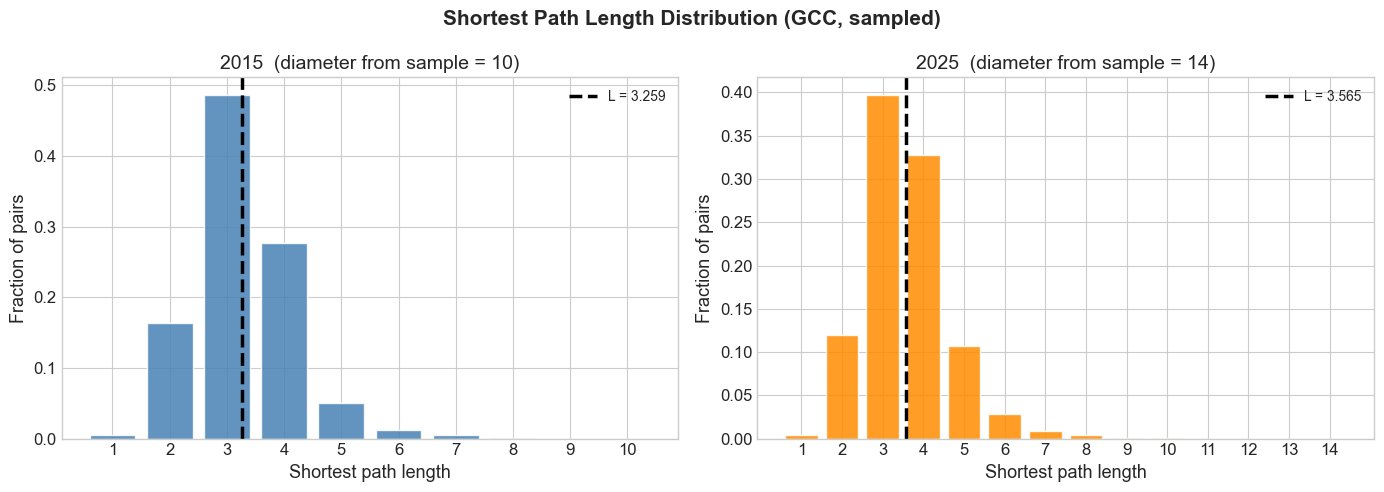


Metric                                     2015     2025  Paper07
Avg path length L (sampled, GCC)         3.2588   3.5650     2.50
Diameter (from sample)                       10       14        —


In [6]:
def sample_avg_path_length(G, n_samples=400, seed=42):
    """
    Approximate average shortest path length by BFS from a random sample
    of source nodes. Returns (apl_estimate, all_sampled_distances_array).
    """
    rng = np.random.default_rng(seed)
    nodes = np.array(list(G.nodes()))
    sample = rng.choice(nodes, size=min(n_samples, len(nodes)), replace=False)

    all_dists = []
    for s in sample:
        lengths = nx.single_source_shortest_path_length(G, s)
        all_dists.extend(v for v in lengths.values() if v > 0)

    arr = np.array(all_dists, dtype=int)
    return float(arr.mean()), arr


print('Extracting Giant Connected Components...')
gcc_2015 = Gu_2015.subgraph(
    max(nx.connected_components(Gu_2015), key=len)).copy()
gcc_2025 = Gu_2025.subgraph(
    max(nx.connected_components(Gu_2025), key=len)).copy()

print(f'2015 GCC: {gcc_2015.number_of_nodes():,} nodes, {gcc_2015.number_of_edges():,} edges')
print(f'2025 GCC: {gcc_2025.number_of_nodes():,} nodes, {gcc_2025.number_of_edges():,} edges')

print('\nComputing sampled path lengths (n_samples=400, ~1-3 min)...')
apl_2015, dists_2015 = sample_avg_path_length(gcc_2015, n_samples=400)
print(f'  2015 done: L = {apl_2015:.4f}')

apl_2025, dists_2025 = sample_avg_path_length(gcc_2025, n_samples=400)
print(f'  2025 done: L = {apl_2025:.4f}')

diam_2015 = int(dists_2015.max())
diam_2025 = int(dists_2025.max())

# ---- Plot distributions ----
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Shortest Path Length Distribution (GCC, sampled)', fontsize=15, fontweight='bold')

for ax, dists, apl, year, color in [
    (axes[0], dists_2015, apl_2015, '2015', 'steelblue'),
    (axes[1], dists_2025, apl_2025, '2025', 'darkorange')
]:
    vals, counts = np.unique(dists, return_counts=True)
    ax.bar(vals, counts / counts.sum(), color=color, edgecolor='white', alpha=0.85)
    ax.axvline(apl, color='black', linestyle='--', lw=2.5, label=f'L = {apl:.3f}')
    ax.set_xlabel('Shortest path length')
    ax.set_ylabel('Fraction of pairs')
    ax.set_title(f'{year}  (diameter from sample = {dists.max()})')
    ax.set_xticks(vals)
    ax.legend()

plt.tight_layout()
plt.savefig(FIG_DIR + '01_path_length.png', dpi=150, bbox_inches='tight')
plt.show()

print(f'\n{"="*60}')
print(f'{"Metric":<38} {"2015":>8} {"2025":>8} {"Paper07":>8}')
print(f'{"="*60}')
print(f'{"Avg path length L (sampled, GCC)":<38} {apl_2015:>8.4f} {apl_2025:>8.4f} {PAPER_2007["path_length"]:>8.2f}')
print(f'{"Diameter (from sample)":<38} {diam_2015:>8,} {diam_2025:>8,} {"—":>8}')


## 6. Small-World Properties

A **small-world network** has:
- Much higher clustering than a random (Erdos-Renyi) graph of the same size and density: γ = C_real / C_rand >> 1
- Similar path length to a random graph: λ = L_real / L_rand ≈ 1
- Small-world coefficient σ = γ / λ >> 1 (Humphries & Gurney 2008)

For ER: C_rand ≈ <k>/N, L_rand ≈ ln(N) / ln(<k>)


In [7]:
def small_world_metrics(Gu, apl, C, label=''):
    N  = Gu.number_of_nodes()
    k  = np.mean([d for _, d in Gu.degree()])

    C_rand = k / N                                          # ER approximation
    L_rand = np.log(N) / np.log(k) if k > 1 else np.inf   # ER approximation

    gamma = C / C_rand   if C_rand > 0 else np.inf
    lam   = apl / L_rand if L_rand > 0 else np.inf
    sigma = gamma / lam  if lam    > 0 else np.inf

    print(f'\n=== Small-World Analysis: {label} ===')
    print(f'  N = {N:,},  <k> = {k:.2f}')
    print(f'  C_real  = {C:.4f}')
    print(f'  C_rand  = {C_rand:.6f}  (ER)')
    print(f'  L_real  = {apl:.4f}  (sampled)')
    print(f'  L_rand  = {L_rand:.4f}  (ER)')
    print(f'  gamma   = C_real / C_rand = {gamma:.1f}  (clustering enrichment)')
    print(f'  lambda  = L_real / L_rand = {lam:.4f}  (path length ratio)')
    print(f'  sigma   = gamma / lambda  = {sigma:.1f}  (sigma >> 1 -> small-world)')

    return {'C_rand': C_rand, 'L_rand': L_rand,
            'gamma': gamma, 'lam': lam, 'sigma': sigma}


sw_2015 = small_world_metrics(Gu_2015, apl_2015, res_c_2015['C'], '2015')
sw_2025 = small_world_metrics(Gu_2025, apl_2025, res_c_2025['C'], '2025')



=== Small-World Analysis: 2015 ===
  N = 7,097,  <k> = 41.07
  C_real  = 0.5223
  C_rand  = 0.005787  (ER)
  L_real  = 3.2588  (sampled)
  L_rand  = 2.3867  (ER)
  gamma   = C_real / C_rand = 90.2  (clustering enrichment)
  lambda  = L_real / L_rand = 1.3654  (path length ratio)
  sigma   = gamma / lambda  = 66.1  (sigma >> 1 -> small-world)

=== Small-World Analysis: 2025 ===
  N = 7,717,  <k> = 36.15
  C_real  = 0.4884
  C_rand  = 0.004685  (ER)
  L_real  = 3.5650  (sampled)
  L_rand  = 2.4949  (ER)
  gamma   = C_real / C_rand = 104.2  (clustering enrichment)
  lambda  = L_real / L_rand = 1.4289  (path length ratio)
  sigma   = gamma / lambda  = 73.0  (sigma >> 1 -> small-world)


## 7. Degree-Degree Correlations

We measure:
- **Assortativity r** (Newman 2002): r < 0 → disassortative (hubs connect to low-degree nodes)
- **KNN k_nn(k)**: average degree of neighbors of degree-k nodes.  
  k_nn(k) ~ k^ν; ν < 0 confirms disassortativity.


Computing assortativity and KNN...
  2015: assortativity r = -0.0694,  KNN slope nu = -0.0145
  2025: assortativity r = -0.0080,  KNN slope nu = 0.0553


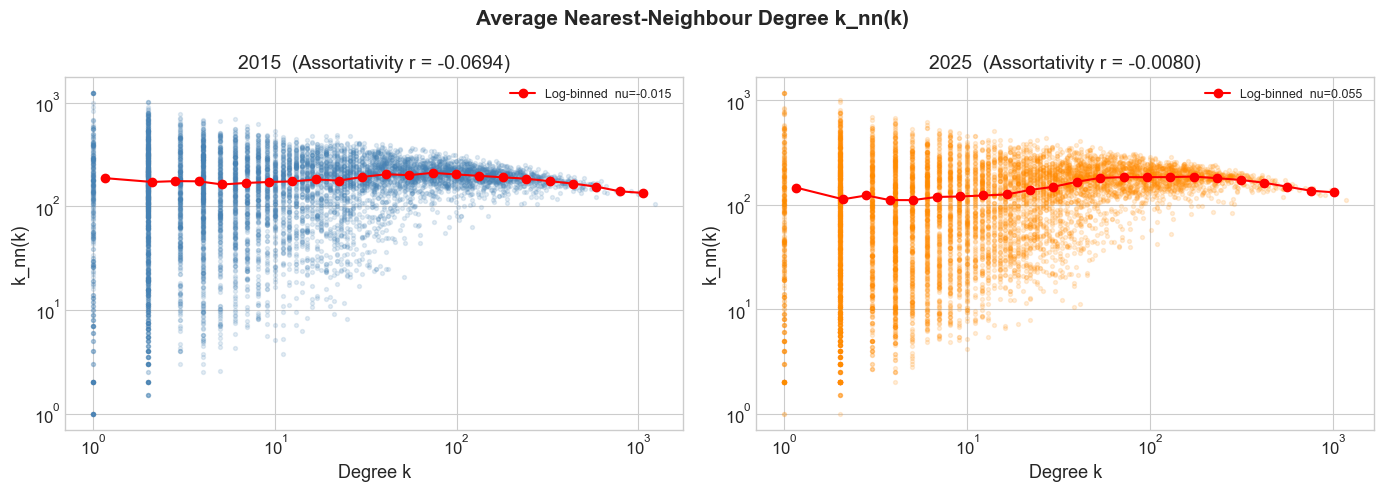


Note: r < 0 indicates disassortativity (hubs connect to low-degree nodes).
      nu < 0 in KNN plot confirms the same disassortative mixing.


In [8]:
def degree_correlation_analysis(Gu, label=''):
    r = nx.degree_assortativity_coefficient(Gu)

    knn  = nx.average_neighbor_degree(Gu)
    deg  = dict(Gu.degree())

    k_all   = np.array([deg[n] for n in Gu.nodes()])
    knn_all = np.array([knn[n] for n in Gu.nodes()])

    # Log-binned k_nn(k)
    if k_all.max() > k_all.min() and k_all.min() > 0:
        bins = np.logspace(np.log10(k_all.min()), np.log10(k_all.max()), 25)
        k_bin, knn_bin = [], []
        for i in range(len(bins) - 1):
            mask = (k_all >= bins[i]) & (k_all < bins[i + 1])
            if mask.sum() > 0:
                k_bin.append(np.sqrt(bins[i] * bins[i + 1]))
                knn_bin.append(np.mean(knn_all[mask]))
        k_bin   = np.array(k_bin)
        knn_bin = np.array(knn_bin)
    else:
        k_bin, knn_bin = k_all, knn_all

    # Fit k_nn(k) ~ k^nu
    valid = (k_bin > 0) & (knn_bin > 0)
    if valid.sum() >= 3:
        nu, _, r2, _, _ = stats.linregress(
            np.log10(k_bin[valid]), np.log10(knn_bin[valid]))
    else:
        nu, r2 = np.nan, np.nan

    print(f'  {label}: assortativity r = {r:.4f},  KNN slope nu = {nu:.4f}')

    return {
        'r': r, 'nu': nu,
        'k_all': k_all, 'knn_all': knn_all,
        'k_bin': k_bin, 'knn_bin': knn_bin
    }


print('Computing assortativity and KNN...')
dc_2015 = degree_correlation_analysis(Gu_2015, '2015')
dc_2025 = degree_correlation_analysis(Gu_2025, '2025')

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Average Nearest-Neighbour Degree k_nn(k)', fontsize=15, fontweight='bold')

for ax, dc, year, color in [
    (axes[0], dc_2015, '2015', 'steelblue'),
    (axes[1], dc_2025, '2025', 'darkorange')
]:
    ax.scatter(dc['k_all'], dc['knn_all'], alpha=0.15, s=8, color=color)
    if len(dc['k_bin']) > 0:
        ax.loglog(dc['k_bin'], dc['knn_bin'], 'o-', color='red', ms=6, lw=1.5,
                  label=f'Log-binned  nu={dc["nu"]:.3f}')
    ax.set_xscale('log')
    ax.set_yscale('log')
    ax.set_xlabel('Degree k')
    ax.set_ylabel('k_nn(k)')
    ax.set_title(f'{year}  (Assortativity r = {dc["r"]:.4f})')
    ax.legend(fontsize=9)

plt.tight_layout()
plt.savefig(FIG_DIR + '01_knn.png', dpi=150, bbox_inches='tight')
plt.show()

print(f'\nNote: r < 0 indicates disassortativity (hubs connect to low-degree nodes).')
print(f'      nu < 0 in KNN plot confirms the same disassortative mixing.')


## 8. Rich-Club Coefficient

phi(k) = fraction of edges between nodes with degree > k out of all possible edges among such nodes.  
Rising phi(k) → rich-club phenomenon (hubs are densely interconnected).


Computing rich-club coefficients...


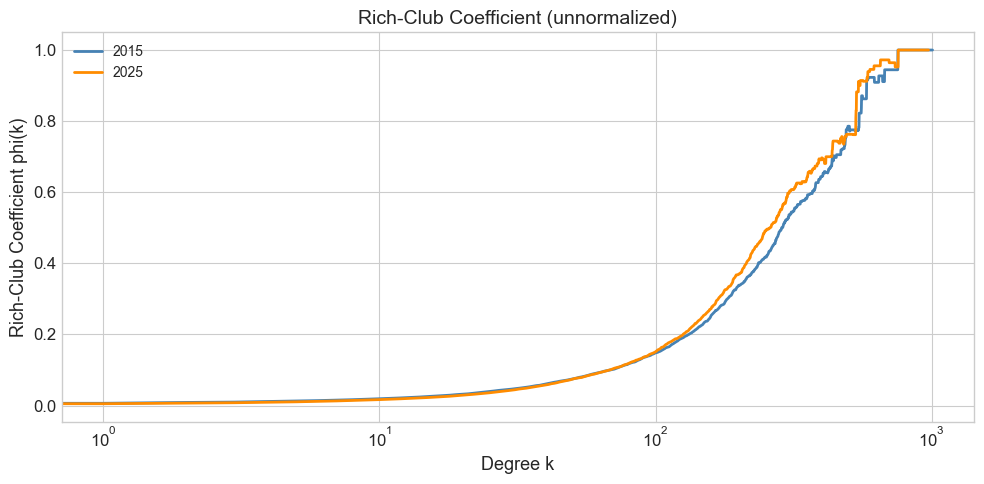

Rising phi(k) indicates that high-degree ports (hubs) are more densely
interconnected than expected — consistent with the paper's findings.


In [9]:
print('Computing rich-club coefficients...')
rc_2015 = nx.rich_club_coefficient(Gu_2015, normalized=False)
rc_2025 = nx.rich_club_coefficient(Gu_2025, normalized=False)

k_rc_2015  = np.array(sorted(rc_2015.keys()))
phi_rc_2015 = np.array([rc_2015[k] for k in k_rc_2015])

k_rc_2025  = np.array(sorted(rc_2025.keys()))
phi_rc_2025 = np.array([rc_2025[k] for k in k_rc_2025])

fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(k_rc_2015, phi_rc_2015, '-', lw=2, label='2015', color='steelblue')
ax.plot(k_rc_2025, phi_rc_2025, '-', lw=2, label='2025', color='darkorange')
ax.set_xscale('log')
ax.set_xlabel('Degree k')
ax.set_ylabel('Rich-Club Coefficient phi(k)')
ax.set_title('Rich-Club Coefficient (unnormalized)')
ax.legend()
plt.tight_layout()
plt.savefig(FIG_DIR + '01_rich_club.png', dpi=150, bbox_inches='tight')
plt.show()

print('Rising phi(k) indicates that high-degree ports (hubs) are more densely')
print('interconnected than expected — consistent with the paper\'s findings.')


## 9. Top Ports by Degree (Betweenness Centrality)



Top 20 ports by degree — 2015
                   port  undirected_degree  in_degree  out_degree
           chn-shanghai               1233        954         932
            bel-antwerp               1007        737         748
nld-rotterdammaasvlakte                999        708         711
          mys-pengerang                910        625         650
          sgp-singapore                827        542         621
           chn-hongkong                804        610         556
             chn-ningbo                779        635         534
          gib-gibraltar                760        560         545
             dnk-skagen                754        517         542
          chn-guangzhou                675        519         467
        mys-pasirgudang                664        444         501
           jpn-yokohama                643        523         463
          nld-rotterdam                620        481         330
         chn-caofeidian                615   

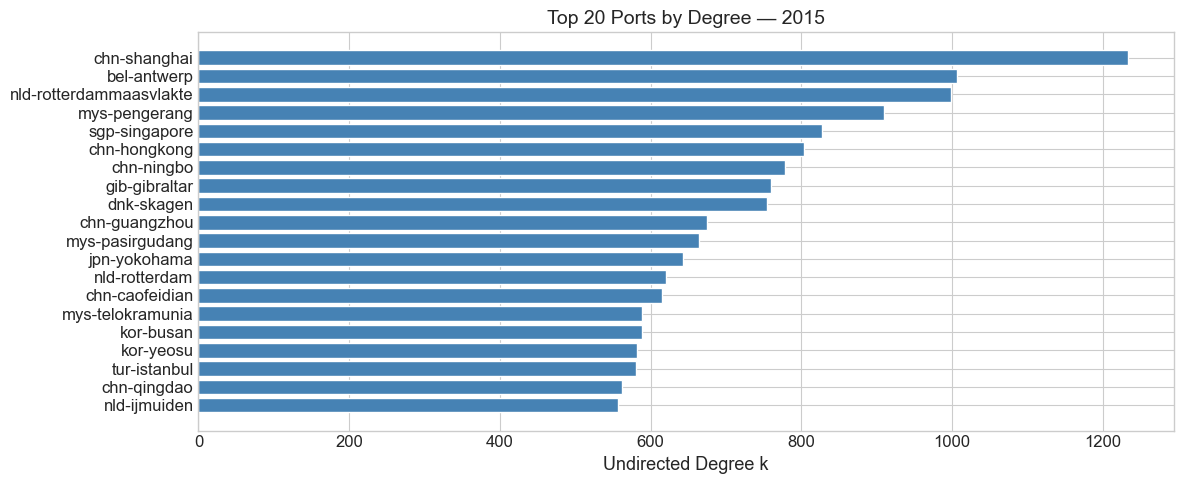


Top 20 ports by degree — 2025
                   port  undirected_degree  in_degree  out_degree
           chn-shanghai               1171        899         921
       mys-telokramunia                974        567         765
            bel-antwerp                901        675         636
nld-rotterdammaasvlakte                846        626         579
             chn-ningbo                829        664         572
          sgp-singapore                771        413         552
          chn-guangzhou                756        568         543
           chn-hongkong                737        552         516
          gib-gibraltar                701        490         528
             dnk-skagen                652        437         483
           chn-shenzhen                618        431         473
          esp-laspalmas                597        402         451
              kor-yeosu                587        430         437
           chn-zhoushan                583   

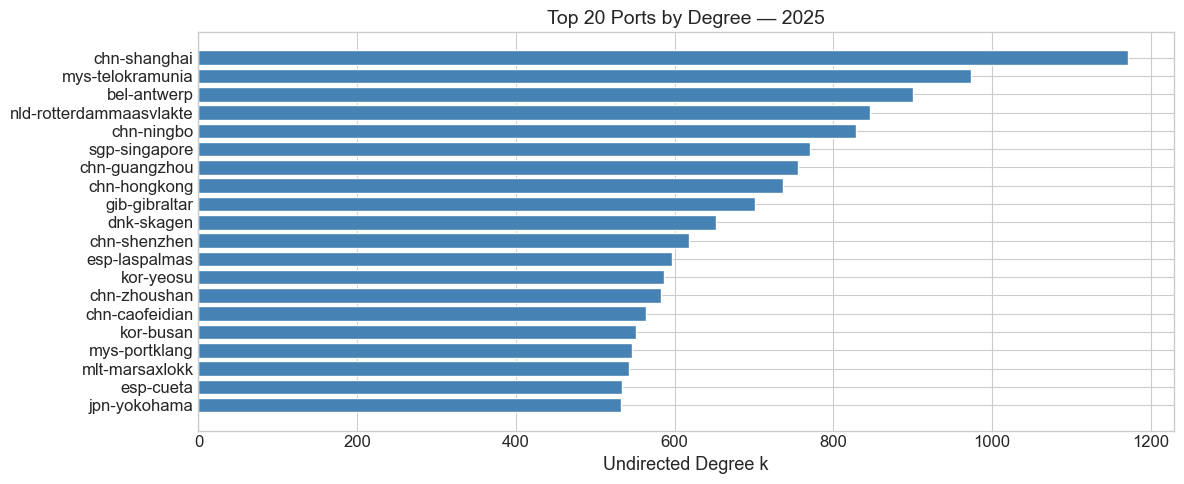

In [10]:
TOP_N = 20

def top_ports_table(Gd, Gu, year, top_n=TOP_N):
    out_deg = dict(Gd.out_degree())
    in_deg  = dict(Gd.in_degree())
    u_deg   = dict(Gu.degree())

    top = sorted(u_deg.items(), key=lambda x: x[1], reverse=True)[:top_n]

    rows = []
    for port, k in top:
        rows.append({
            'port': port,
            'undirected_degree': k,
            'in_degree': in_deg.get(port, 0),
            'out_degree': out_deg.get(port, 0),
        })

    df_top = pd.DataFrame(rows)
    print(f'\nTop {top_n} ports by degree — {year}')
    print(df_top.to_string(index=False))

    # Bar chart
    fig, ax = plt.subplots(figsize=(12, 5))
    ax.barh(df_top['port'][::-1], df_top['undirected_degree'][::-1],
            color='steelblue', edgecolor='white')
    ax.set_xlabel('Undirected Degree k')
    ax.set_title(f'Top {top_n} Ports by Degree — {year}')
    plt.tight_layout()
    plt.savefig(FIG_DIR + f'01_top_ports_{year}.png', dpi=150, bbox_inches='tight')
    plt.show()

    return df_top


top_2015 = top_ports_table(Gd_2015, Gu_2015, '2015')
top_2025 = top_ports_table(Gd_2025, Gu_2025, '2025')


## 10. Summary Table — 2015 vs 2025 vs Kaluza et al. 2007


In [11]:
N_2015 = Gu_2015.number_of_nodes()
N_2025 = Gu_2025.number_of_nodes()
E_2015 = Gu_2015.number_of_edges()
E_2025 = Gu_2025.number_of_edges()
Ed_2015 = Gd_2015.number_of_edges()
Ed_2025 = Gd_2025.number_of_edges()

rows = [
    ('Year',                           '2015',                          '2025',                          '2007 (paper)'),
    ('Data type',                       'Cargo+Container',               'Cargo+Container',               'All cargo ships'),
    ('Nodes N (ports)',                 f'{N_2015:,}',                   f'{N_2025:,}',                   '951'),
    ('Directed edges',                  f'{Ed_2015:,}',                  f'{Ed_2025:,}',                  '—'),
    ('Undirected edges',                f'{E_2015:,}',                   f'{E_2025:,}',                   '—'),
    ('Density (undirected)',            f'{nx.density(Gu_2015):.6f}',    f'{nx.density(Gu_2025):.6f}',    '—'),
    ('Mean undirected degree <k>',      f'{deg_stats["2015"]["mean_undirected"]:.2f}',
                                        f'{deg_stats["2025"]["mean_undirected"]:.2f}', '44.61'),
    ('Max degree',                      f'{deg_stats["2015"]["max_degree"]:,}',
                                        f'{deg_stats["2025"]["max_degree"]:,}',  '—'),
    ('Clustering coefficient C',        f'{res_c_2015["C"]:.4f}',        f'{res_c_2025["C"]:.4f}',        '0.490'),
    ('C(k) decay exponent beta',        f'{res_c_2015["beta"]:.3f}',     f'{res_c_2025["beta"]:.3f}',     '—'),
    ('Avg path length L (sampled GCC)', f'{apl_2015:.4f}',               f'{apl_2025:.4f}',               '2.500'),
    ('Diameter (from sample)',          f'{diam_2015}',                  f'{diam_2025}',                  '—'),
    ('Assortativity r',                 f'{dc_2015["r"]:.4f}',           f'{dc_2025["r"]:.4f}',           '—'),
    ('KNN slope nu',                    f'{dc_2015["nu"]:.4f}',          f'{dc_2025["nu"]:.4f}',          '—'),
    ('Power-law exponent mu (MLE)',      f'{deg_stats["2015"]["mu"]:.3f}',f'{deg_stats["2025"]["mu"]:.3f}','1.710'),
    ('GCC size (% of N)',               f'{gcc_2015.number_of_nodes()/N_2015*100:.1f}%',
                                        f'{gcc_2025.number_of_nodes()/N_2025*100:.1f}%', '—'),
    ('Small-world sigma',               f'{sw_2015["sigma"]:.1f}',       f'{sw_2025["sigma"]:.1f}',       '—'),
    ('Small-world gamma (C/C_rand)',     f'{sw_2015["gamma"]:.1f}',       f'{sw_2025["gamma"]:.1f}',       '—'),
]

df_summary = pd.DataFrame(rows, columns=['Metric', '2015', '2025', 'Paper 2007'])

print()
print('=' * 80)
print('  GCSN UNWEIGHTED NETWORK — SUMMARY TABLE')
print('  Reference: Kaluza et al. (2010), J. R. Soc. Interface, doi:10.1098/rsif.2009.0495')
print('=' * 80)
print(df_summary.to_string(index=False))
print('=' * 80)

# Save as CSV
df_summary.to_csv('../Figures/01_summary_unweighted.csv', index=False)
print('\nSummary saved to ../Figures/01_summary_unweighted.csv')



  GCSN UNWEIGHTED NETWORK — SUMMARY TABLE
  Reference: Kaluza et al. (2010), J. R. Soc. Interface, doi:10.1098/rsif.2009.0495
                         Metric            2015            2025      Paper 2007
                           Year            2015            2025    2007 (paper)
                      Data type Cargo+Container Cargo+Container All cargo ships
                Nodes N (ports)           7,097           7,717             951
                 Directed edges         188,545         182,300               —
               Undirected edges         145,745         139,499               —
           Density (undirected)        0.005788        0.004686               —
     Mean undirected degree <k>           41.07           36.15           44.61
                     Max degree           1,233           1,171               —
       Clustering coefficient C          0.5223          0.4884           0.490
       C(k) decay exponent beta           0.296           0.273          